# Notebook for testing and demonstrating ring piercing algorithms

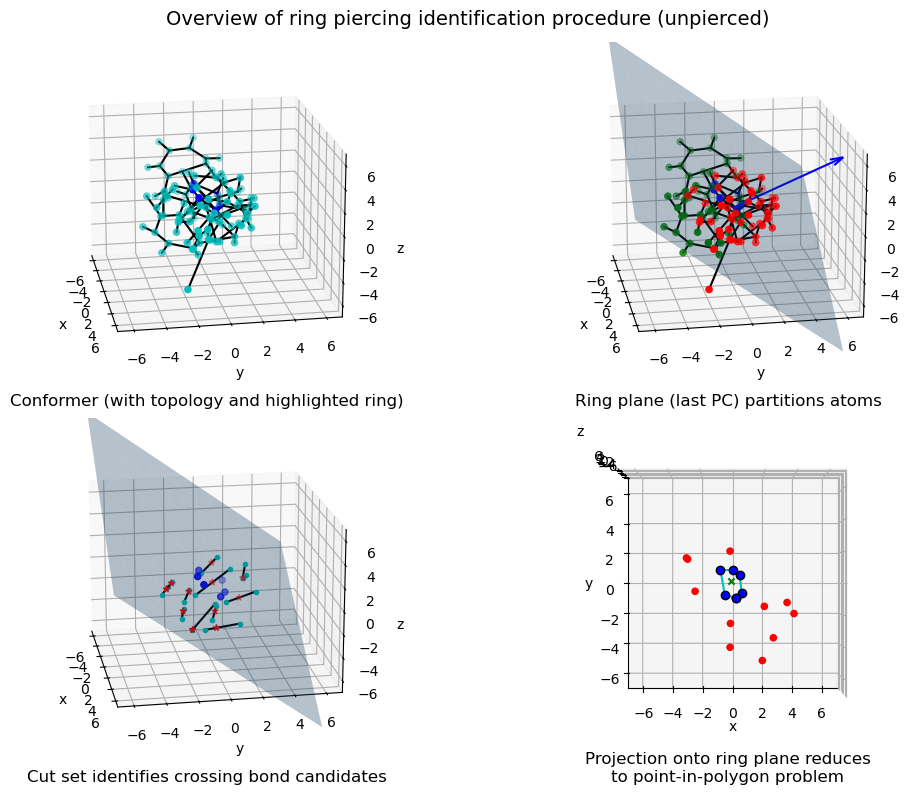

In [2]:
from pathlib import Path

import numpy as np
from scipy.spatial import Delaunay

import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib notebook
# %matplotlib ipympl

from rdkit import Chem


# RDKit setup
struct_dir : Path = Path('ring_piercing')
mol_sdf_name : str = 'distorted.sdf'
# mol_sdf_name : str = 'tangled.sdf'
# mol_sdf_name : str = 'small.sdf'

mol_sdf_path = struct_dir / mol_sdf_name
ring_idx : int = 2 # which ring in the molecule to focus on

# geometric config
conductor : np.ndarray = np.array([0, 0, 1], dtype=float) # by default, align ring axis along the +z-axis

# plot options
affix : str = 'unpierced'

nrows : int = 2
ncols : int = 2
scale  : float = 8
aspect : float = 3/2
ax_min, ax_max = -7, 7

azim = 45
elev = 30
roll = 0

# initialize plots
ax_range = np.arange(ax_min, ax_max)
plt.close()
fig, axes = plt.subplots(nrows, ncols, subplot_kw={'projection' : '3d'}, figsize=(aspect*scale, scale))
fig.suptitle(f'Overview of ring piercing identification procedure ({affix})', fontsize=14)

# prepare molecule geometry and topology
with Chem.SDMolSupplier(str(mol_sdf_path), sanitize=False, removeHs=False) as suppl:
    mol = suppl[0]
    Chem.SanitizeMol(mol)
positions = mol.GetConformer(0).GetPositions()
bonded_atom_idxs = np.array([(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()) for bond in mol.GetBonds()])

# perform ring calculations
ring_atom_idxs = list(mol.GetRingInfo().AtomRings()[ring_idx]) # convert to list to allow flexible numpy indexing
ring_bond_idxs = bonded_atom_idxs[np.logical_and.reduce(np.isin(bonded_atom_idxs, ring_atom_idxs), axis=1)]
is_in_ring = np.zeros(len(positions), dtype=bool)
is_in_ring[ring_atom_idxs] = True

# local origin and basis for ring
## locate and subtract off center
ring_positions = positions[ring_atom_idxs]
ring_center = np.mean(ring_positions, axis=0)
positions_centered = positions - ring_center
ring_positions = positions_centered[ring_atom_idxs]

## identify ring normal, defined as the minimum-variance direction (assuming oblate ring)
U, S, Vh = np.linalg.svd(ring_positions, full_matrices=False) # NOTE: SVD here requires centered ring positions (i.e. subtracting mean)
ring_axes = Vh.T                # transpose places eigenvectors into column-order; basis guaranteed to be orthogonal, since covariance matrix is real and symmetric
ring_normal = ring_axes[:, -1]  # NOTE: no need to sort by eigenvalue, linalg.svd already sorts in descending order by singular value

## determine projections of ring points onto ring plane
O = planar_projector = np.eye(3, dtype=float) - np.outer(ring_normal, ring_normal)/np.inner(ring_normal, ring_normal) # !NOTE!: the "lack" of a 2 coefficient is deliberate, as this is NOT a Householder matrix (project onto -but not through- plane)
ring_positions_planar = ring_positions @ O.T

# determine orientation of all atoms relative to ring plane:
# *  1 <=> in front of ring
# *  0 <=> parallel to/part of ring
# * -1 <=> behind ring
ring_affiliations = np.sign(np.dot(positions_centered, ring_normal)).astype(int) # NOTE: use of uncentered postiions is NOT a mistake (subtracting center alters dot product)
ring_affiliations[ring_atom_idxs] = 0 # explicitly clamp ring atoms as being parallel (even if not strictly geometrically in-plane)
spanning_bond_idxs = (np.prod(ring_affiliations[bonded_atom_idxs], axis=1) == -1) # given A = {-1, 0, 1}, the only pairs from AxA which multiply to -1 are (1, -1) and (-1, 1)
spanning_bond_atom_idxs = bonded_atom_idxs[spanning_bond_idxs, :]

# interpolate spanning bonds and solve for ring plane crossings
spanning_positions = positions_centered[spanning_bond_atom_idxs]
bond_starts, bond_ends = spanning_positions[:, 0, :], spanning_positions[:, 1, :]
bond_vectors = bond_ends - bond_starts

t_intersects = -np.dot(bond_starts, ring_normal) / np.dot(bond_vectors, ring_normal) # NOTE: negative sign comes from np.dot(center - start, normal), since center is now at the origin
bond_plane_intersections = bond_starts + bond_vectors*t_intersects[:, None] # plug parameter back in (need to broadcast!) to solve for bond-plane intersections
t_is_supported = (t_intersects >= 0) & (t_intersects <= 1) # since physically a bond only exists between its atoms, the LERP is only supported on t in [0, 1]

# apply orthogonal transformation to align ring normal direction with the z-axis (the "conductor")
conductor = np.array([0, 0, 1], dtype=float) # technically a parameter, but for polygon intersection tests we need this to be one of the standard basis vectors (picked z arbitrarily)
diff = ring_normal - conductor
H = np.eye(3, dtype=float) - 2*np.outer(diff, diff)/np.inner(diff, diff) # compute Householder matrix which reflects ring normal onto conductor

ring_positions_2d = ring_positions_planar @ H.T
assert np.allclose(ring_positions_2d[:, -1], 0.0) # double-check that the above manipulations have aligned everything as expected
ring_positions_2d = ring_positions_2d[:, :-1]

intersections_2d = bond_plane_intersections @ H.T
assert np.allclose(intersections_2d[:, -1], 0.0) # double-check that the above manipulations have aligned everything as expected
intersections_2d = intersections_2d[:, :-1]

## at last, identify the indices of bonded atom pairs which intersect the ring
tri = Delaunay(ring_positions_2d)
pierces_ring : np.ndarray[bool] = (tri.find_simplex(intersections_2d) != -1) # points not in a simplex (i.e. not intersecting the interior of the ring) are assigned to simplex "-1"
piercing_pair_idxs = spanning_bond_atom_idxs[pierces_ring] 

# plot algorithm step-by-step
azim = -10
elev = 18
for ax in axes.flatten():
    ax.azim = azim
    ax.elev = elev
    ax.roll = roll
    for char in 'xyz':
        getattr(ax, f'set_{char}label')(char)
        getattr(ax, f'set_{char}lim')(ax_min, ax_max)
    
## plot initial molecule coordinates and 
ax_mol = axes[0,0]
ax_mol.set_title('Conformer (with topology and highlighted ring)', y=-0.1)

ax_mol.scatter(*positions[ is_in_ring].T, color='b')
ax_mol.scatter(*positions[~is_in_ring].T, color='c')
for bond_idx_pair in bonded_atom_idxs:
    ax_mol.plot(*positions[bond_idx_pair, :].T, 'k')

## plot atoms by ring affiliation
in_front_idxs = np.where(ring_affiliations ==  1)[0] # annoyingly, returned as tuple, as artifact of np.nonzero
parallel_idxs = np.where(ring_affiliations ==  0)[0] # annoyingly, returned as tuple, as artifact of np.nonzero
behind_idxs   = np.where(ring_affiliations == -1)[0] # annoyingly, returned as tuple, as artifact of np.nonzero

ax_affil = axes[0, 1]
ax_affil.set_title('Ring plane (last PC) partitions atoms', y=-0.1)

ax_affil.quiver(*(ring_center - ring_center).T, *ring_normal.T, length=10, arrow_length_ratio=0.1, color='b')
ax_affil.scatter(*positions[in_front_idxs].T, color='r') # points "in front"
ax_affil.scatter(*positions[parallel_idxs].T, color='b')
ax_affil.scatter(*positions[behind_idxs].T, color='g') # points " behind"
for bond_idx_pair in bonded_atom_idxs:
    ax_affil.plot(*positions[bond_idx_pair, :].T, 'k')
    
d = -np.dot(ring_center, ring_normal) # affine term in equation of plane
xx, yy = np.meshgrid(ax_range, ax_range)
z = -(ring_normal[0]*xx + ring_normal[1]*yy + d) / ring_normal[2]
ax_affil.plot_surface(xx, yy, z, alpha=0.3) # plot ring plane

## plot spanning bonds and their planar intersections
ax_span = axes[1, 0]
ax_span.set_title('Cut set identifies crossing bond candidates', y=-0.1)

ax_span.scatter(*positions_centered[parallel_idxs].T, color='b')
ax_span.plot_surface(xx, yy, z, alpha=0.3) # plot ring plane
for idxs in spanning_bond_atom_idxs:
    ax_span.plot(*positions_centered[idxs, :].T, '.-', color='k', mfc='c', mec='c')
ax_span.scatter(*bond_plane_intersections.T, marker='*', color='r')

## plot projection of ring and intersection points into 2 dimensions
ax_proj = axes[1, 1]
ax_proj.set_title('Projection onto ring plane reduces\nto point-in-polygon problem', y=-0.1)

ax_proj.azim = -90
ax_proj.elev = 90
ax_proj.plot(*positions_centered[np.hstack([ring_atom_idxs, [ring_atom_idxs[0]]])].T, 'c-o', mfc='b', mec='k')

ax_proj.scatter(*intersections_2d[~pierces_ring].T, color='r', marker='o')
ax_proj.scatter(*intersections_2d[pierces_ring].T, color='g', marker='x')

fig.tight_layout()
# fig.savefig(f'ring_piercing_demo_{affix}.png', bbox_inches='tight')
plt.show()

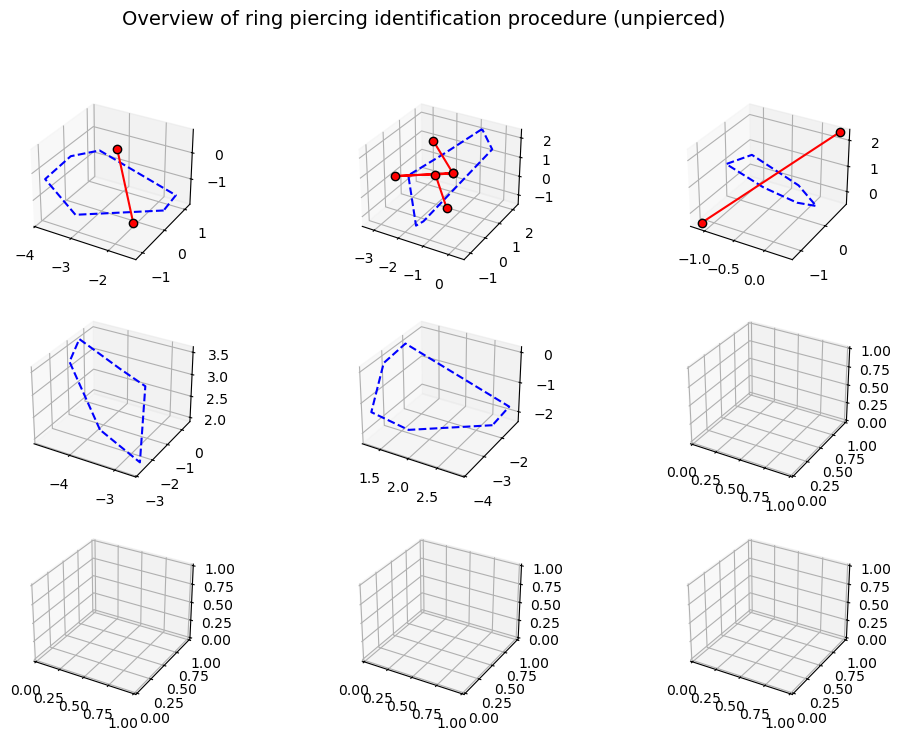

In [3]:
from math import ceil, sqrt
from src.utils.piercing import assess_ring_piercing


plt.close()
vs = assess_ring_piercing(mol)
N = ceil(sqrt(len(vs)))
fig, axes = plt.subplots(N, N, subplot_kw={'projection' : '3d'}, figsize=(aspect*scale, scale))
fig.suptitle(f'Overview of ring piercing identification procedure ({affix})', fontsize=14)

for ax, (ring_idxs, piercing_idxs) in zip(axes.flatten(), vs.items()):
    ax.plot(*positions[list(ring_idxs) + [ring_idxs[0]]].T, 'b--')
    ax.plot(*positions[list(piercing_idxs)].T, 'r-o', mec='k')
plt.show()

In [6]:
p = assess_ring_piercing(mol)
print(p)

{(10, 12, 14, 16, 18, 9): ((36, 38),), (32, 34, 36, 38, 40, 31): ((9, 18), (56, 58), (58, 59)), (54, 56, 58, 60, 62, 53): ((31, 40),), (72, 74, 76, 78, 80, 71): (), (95, 97, 99, 101, 103, 94): ()}


In [10]:
import json

with open('test.json', 'w') as file:
    json.dump({'ring_idxs' : {str(k) : v for k, v in p.items()}}, file, indent=4)

In [5]:
for sdfile in struct_dir.glob('*.sdf'):
    print(sdfile.stem)
    with Chem.SDMolSupplier(sdfile, sanitize=False, removeHs=False) as suppl:
        mol = suppl[0]
        Chem.SanitizeMol(mol)

    vs = assess_ring_piercing(mol)
    print(any(vs.values()), vs)

control
False {(6, 8, 10, 13, 15, 0): (), (23, 25, 27, 30, 32, 17): (), (40, 42, 44, 47, 49, 34): (), (58, 60, 62, 65, 67, 51): (), (71, 73, 75, 78, 80, 70): ()}
tangled
True {(2, 4, 6, 50, 52, 1): ((189, 190),), (9, 11, 13, 46, 48, 8): ((181, 183),), (16, 18, 20, 34, 36, 15): (), (23, 25, 27, 30, 32, 22): (), (58, 60, 61, 105, 107, 57): ((382, 492),), (62, 61, 60, 103, 64): (), (66, 71, 76, 93, 98, 65): ((391, 430),), (78, 77, 82, 81, 80): (), (84, 86, 88, 91, 80, 81): (), (111, 113, 115, 159, 161, 110): ((298, 299),), (118, 120, 122, 155, 157, 117): ((290, 292),), (125, 127, 129, 143, 145, 124): (), (132, 134, 136, 139, 141, 131): (), (167, 169, 170, 214, 216, 166): (), (171, 170, 169, 212, 173): (), (175, 180, 185, 202, 207, 174): (), (187, 186, 191, 190, 189): ((4, 6),), (193, 195, 197, 200, 189, 190): ((1, 2), (333, 377)), (220, 222, 224, 268, 270, 219): ((80, 91), (88, 89), (88, 91), (407, 408)), (227, 229, 231, 264, 266, 226): (), (234, 236, 238, 252, 254, 233): (), (241, 243, 2